# Plot final results

In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import sys
sys.path.append("../")

from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import display


from experiment_utils import (compute_experiment_result,plot_completion_rate_by_episode,
                              summarize_performance,plot_completion_rate_by_episode,plot_dimension_profile,
                              plot_token_completion_bars)
from adam_python.agentic_forge.checkpointers import SqliteSaver,forge_checkpointer,CheckpointerConfig

EXP_NAME=Path("final_experiments")
DST_DATA_PATH=Path("./final_experiments/") / EXP_NAME
EP_DEF_YAML=Path("../episodes_definition.yaml")

out_all,out_agg=compute_experiment_result(DST_DATA_PATH,save=False,from_csv=True)

### 📊 Completion Rate x Episode x Model

This plot shows the **Completion Rate (solutionCheck)** for each episode (task) and model.  
Each bar represents the mean completion rate of a model for a specific episode.  
Episodes on the x-axis are **ordered by C/D Level (tax)**, shown in the label next to each episode name.

**Purpose:**  
To visualize how different models perform across episodes of increasing difficulty, and to compare their consistency.


c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1778: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="episode_label", columns="_group", values=metric_col, aggfunc=agg)


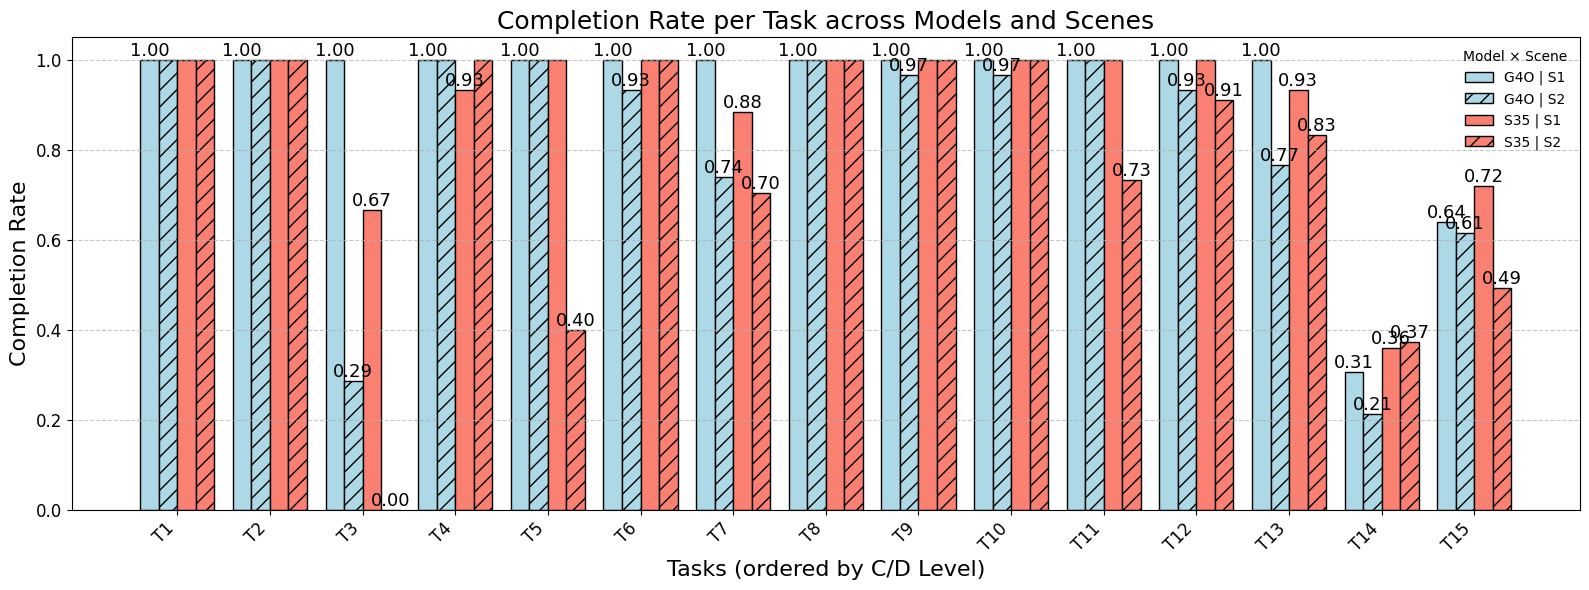

_group,G4O | S1,G4O | S2,S35 | S1,S35 | S2
episode_label,,,,
T1,1.000000,1.000000,1.000000,1.000000
T2,1.000000,1.000000,1.000000,1.000000
T3,1.000000,0.285714,0.666667,0.000000
T4,1.000000,1.000000,0.933333,1.000000
T5,1.000000,1.000000,1.000000,0.400000
T6,1.000000,0.933333,1.000000,1.000000
T7,1.000000,0.738933,0.883933,0.703000
T8,1.000000,1.000000,1.000000,1.000000
T9,1.000000,0.966667,1.000000,1.000000


In [14]:
style_map = {
    "S35|S1": ("salmon", None),
    "S35|S2": ("salmon", "//"),
    "G4O|S1": ("lightblue", None),
    "G4O|S2": ("lightblue", "//"),
}

plot_completion_rate_by_episode(
    out_agg[out_agg.objectIdentifier == "SEM"],
    by=("model", "scene"),
    episode_col="taskId",
    metric_col="solutionCheck",
    tax_col="tax",
    title="Completion Rate per Task across Models and Scenes",
    style_map=style_map,
    annot_fontsize=13,
    figsize=(16, 6),
    by_name_map={"model": "Model", "scene": "Scene"},
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    title_fontsize=18,
    intra_group_spacing=0.0,
    show_std=False,
    std_col=False,   # <<< QUI USI LA DEVIAZIONE STANDARD PRECALCOLATA)
    annot_offset_even=0,
    annot_offset_odd=0,
    xtick_labelsize=12.0,
    ytick_labelsize=12,
    
)


In [15]:
out_agg[["tax","taskId"]].drop_duplicates().sort_values(by=["tax","taskId"])

,tax,taskId
0,1.0,T1
28,2.0,T2
32,2.0,T3
36,4.0,T4
40,5.0,T5
44,6.0,T6
48,6.0,T7
52,8.0,T8
56,9.0,T9
12,10.0,T12


In [ ]:
(
    out_agg[["episode_col", "tax_col"]]
    .drop_duplicates()
    .sort_values(["tax_col", "episode_col"])
)


In [20]:
(out_agg["solutionCheck_std"]+out_agg["solutionCheck"]).max()#].map(lambda (std,m): print(std,m))

np.float64(1.2140393356054124)

In [15]:
out_agg[out_agg.episodeId=="S1-T3-C3-PL-HR-S35-SEM-ABS"][["solutionCheck_std","solutionCheck"]]

,solutionCheck_std,solutionCheck
35,0.48795,0.666667


c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1705: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="episode_label", columns="_group", values=metric_col, aggfunc=agg)
c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1723: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="episode_label", columns="_group", values=metric_col, aggfunc="std")


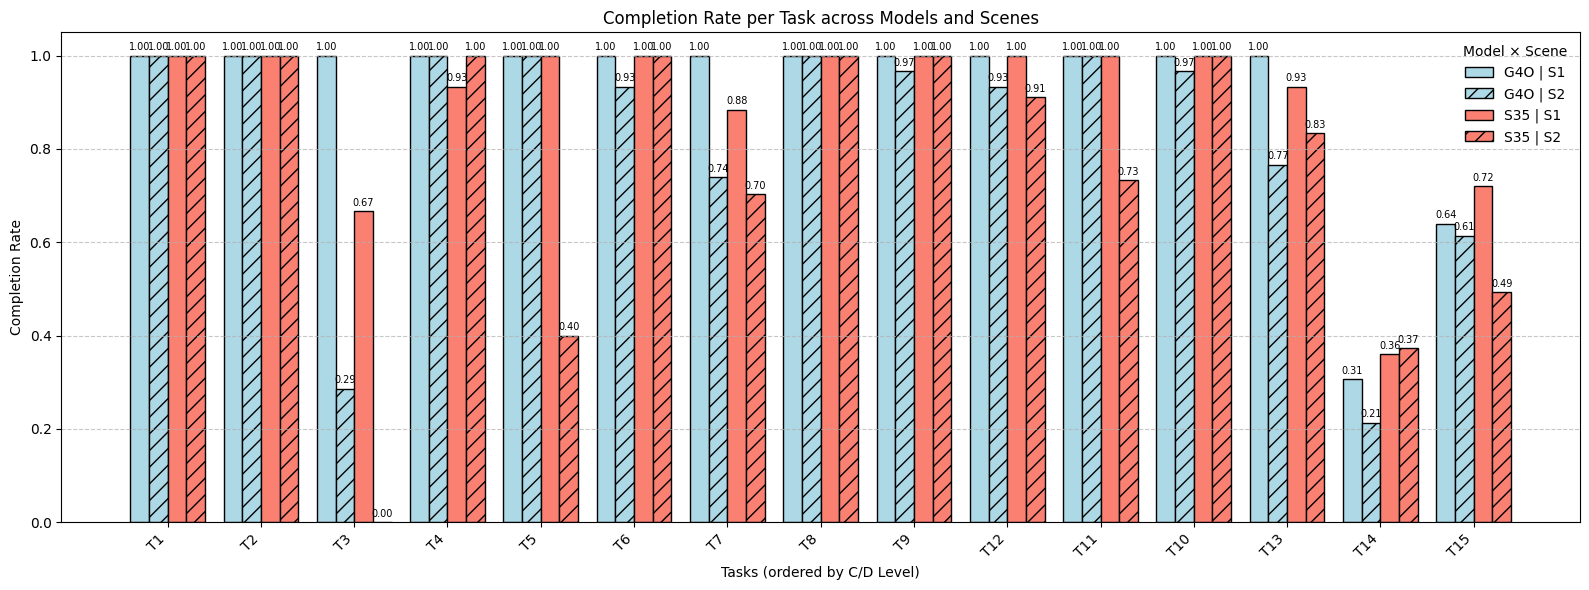

_group,G4O | S1,G4O | S2,S35 | S1,S35 | S2
episode_label,,,,
T1,1.000000,1.000000,1.000000,1.000000
T2,1.000000,1.000000,1.000000,1.000000
T3,1.000000,0.285714,0.666667,0.000000
T4,1.000000,1.000000,0.933333,1.000000
T5,1.000000,1.000000,1.000000,0.400000
T6,1.000000,0.933333,1.000000,1.000000
T7,1.000000,0.738933,0.883933,0.703000
T8,1.000000,1.000000,1.000000,1.000000
T9,1.000000,0.966667,1.000000,1.000000


In [5]:
style_map={
    "S35|S1":("salmon",None),
    "S35|S2":("salmon","//"),
    "G4O|S1":("lightblue",None),
    "G4O|S2":("lightblue","//"),
    }

plot_completion_rate_by_episode(out_agg[out_agg.objectIdentifier=="SEM"],by=("model","scene"),title="Completion Rate per Task across Models and Scenes",
                                style_map=style_map,
                                annot_fontsize=7,figsize=(16,6),
                                by_name_map={"model":"Model","scene":"Scene"},
                                errorbar_linewidth=1,
                                errorbar_capsize=10
                                )

In [ ]:
empty_messages_g4o/total_run_g4o,empty_messages_s35/total_run_s35

(0.005605381165919282, 0.021205357142857144)

c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1727: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="episode_label", columns="_group", values=metric_col, aggfunc=agg)


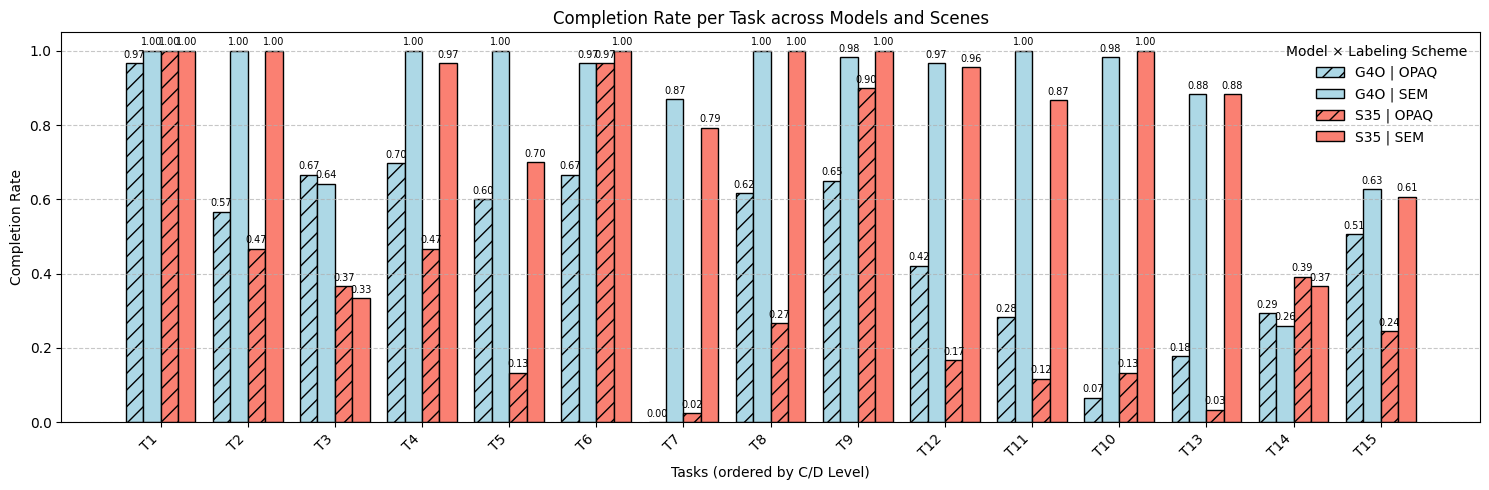

_group,G4O | OPAQ,G4O | SEM,S35 | OPAQ,S35 | SEM
episode_label,,,,
T1,0.966667,1.000000,1.000000,1.000000
T2,0.566667,1.000000,0.466667,1.000000
T3,0.666667,0.642857,0.366667,0.333333
T4,0.697619,1.000000,0.466667,0.966667
T5,0.600000,1.000000,0.133333,0.700000
T6,0.666667,0.966667,0.966667,1.000000
T7,0.000000,0.869467,0.024067,0.793467
T8,0.616667,1.000000,0.266667,1.000000
T9,0.650000,0.983333,0.900000,1.000000


In [10]:
style_map={
    "S35|SEM":("salmon",None),
    "S35|OPAQ":("salmon","//"),
    "G4O|SEM":("lightblue",None),
    "G4O|OPAQ":("lightblue","//"),
    }

plot_completion_rate_by_episode(out_agg,by=("model","objectIdentifier"),title="Completion Rate per Task across Models and Scenes",
                                style_map=style_map,
                                annot_fontsize=7,figsize=(15,5),
                                by_name_map={"model":"Model","objectIdentifier":"Labeling Scheme"}
                                )

c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1715: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="episode_label", columns="_group", values=metric_col, aggfunc=agg)


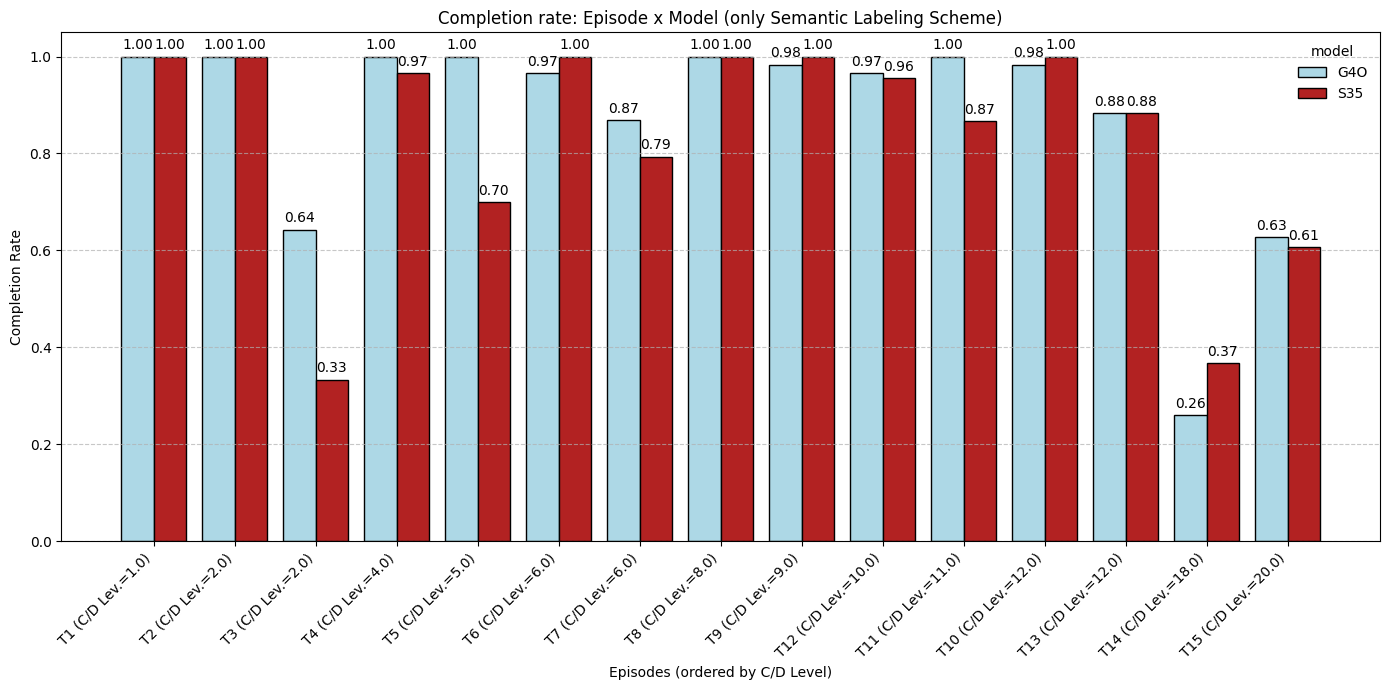

_group,G4O,S35
episode_label,,
T1 (C/D Lev.=1.0),1.000000,1.000000
T2 (C/D Lev.=2.0),1.000000,1.000000
T3 (C/D Lev.=2.0),0.642857,0.333333
T4 (C/D Lev.=4.0),1.000000,0.966667
T5 (C/D Lev.=5.0),1.000000,0.700000
T6 (C/D Lev.=6.0),0.966667,1.000000
T7 (C/D Lev.=6.0),0.869467,0.793467
T8 (C/D Lev.=8.0),1.000000,1.000000
T9 (C/D Lev.=9.0),0.983333,1.000000


In [21]:
style_map={"G4O":("lightblue",None),
           "S35":("firebrick",None)}
plot_completion_rate_by_episode(out_agg[out_agg.objectIdentifier=="SEM"],by=("model",),title="Completion rate: Episode x Model (only Semantic Labeling Scheme)",
                                annot_fontsize=10,style_map=style_map)

### 🧭 Completion Rate x model x Dominant C/D dimension

This plot summarizes how each model performs across the **three main C/D (Capabilities / Difficulties) dimensions**:
**Action**, **Relation**, and **Reference**.

#### 🔹 What is the *Dominant C/D dimension*?

Each task (episode) is composed of three underlying **capability/difficulty components**:
- **Action Level (taxAct)** → related to physical or procedural capabilities (e.g., manipulation, movement, sequencing).
- **Relation Level (taxRel)** → related to relational or spatial reasoning capabilities (e.g., understanding relations, geometry, cause-effect).
- **Reference Level (taxRef)** → related to recognition and referencing capabilities (e.g., identifying entities, attributes, patterns).

Their sum defines the **overall C/D Level** of the task:
> `tax = taxAct + taxRel + taxRef`

To identify which capability/difficulty component **dominates** a task, the function computes the normalized contributions:
> `fracAct = taxAct / tax`  
> `fracRel = taxRel / tax`  
> `fracRef = taxRef / tax`

Then, for each task, it selects the **dominant dimension**:
> `dominant_dim = argmax(fracAct, fracRel, fracRef)`

That is, the dimension with the highest relative contribution to total task complexity.

#### 🔹 What the chart shows

For each **model**, the chart displays the **average Completion Rate** (solutionCheck)
computed over all tasks *dominated* by each C/D dimension.

The x-axis includes the **mean dominance ratio** — shown both as a **simplified fraction** and a **percentage** —
representing how much that dimension typically contributes to total task complexity.

Example label:
> `Action (3/7 | 42.9%)`

means that, on average, the *Action* component represents about 3/7 (≈43%) of the total C/D Level for Action-dominant tasks.

#### 🔹 Purpose

To provide a clear overview of how each model behaves across the three **Capabilities/Difficulties dimensions**,  
highlighting whether it tends to perform better on:
- **Action-dominant** tasks (procedural or manipulative reasoning),
- **Relation-dominant** tasks (relational or structural reasoning), or
- **Reference-dominant** tasks (identificative or perceptual reasoning).

In other words, this visualization gives each model a **C/D performance fingerprint**.


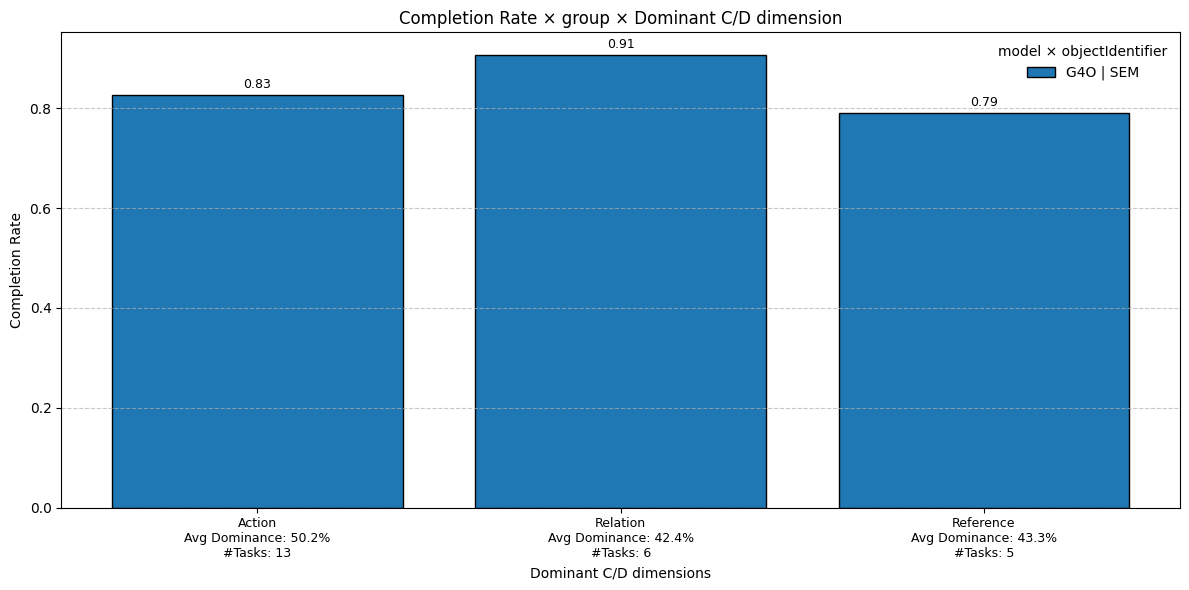

In [4]:
completion_df,dimension_dominance_df,task_dominance_df=plot_dimension_profile(out_agg,by=("model","objectIdentifier"))

c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:1976: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=legend_title, loc=legend_loc, ncol=legend_ncol, frameon=legend_frame)


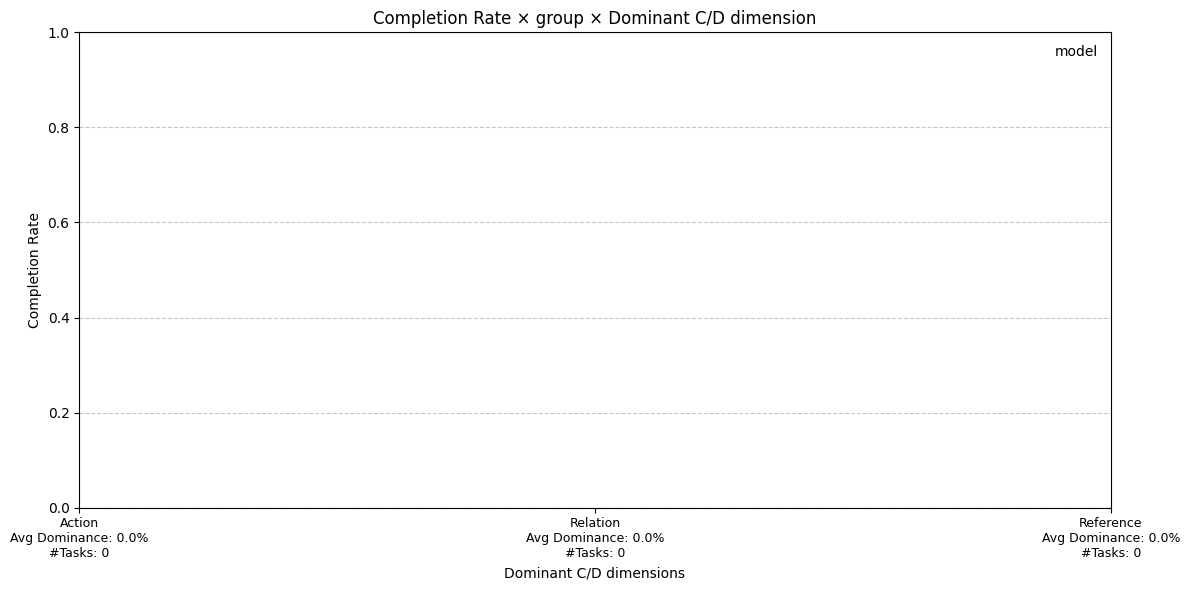

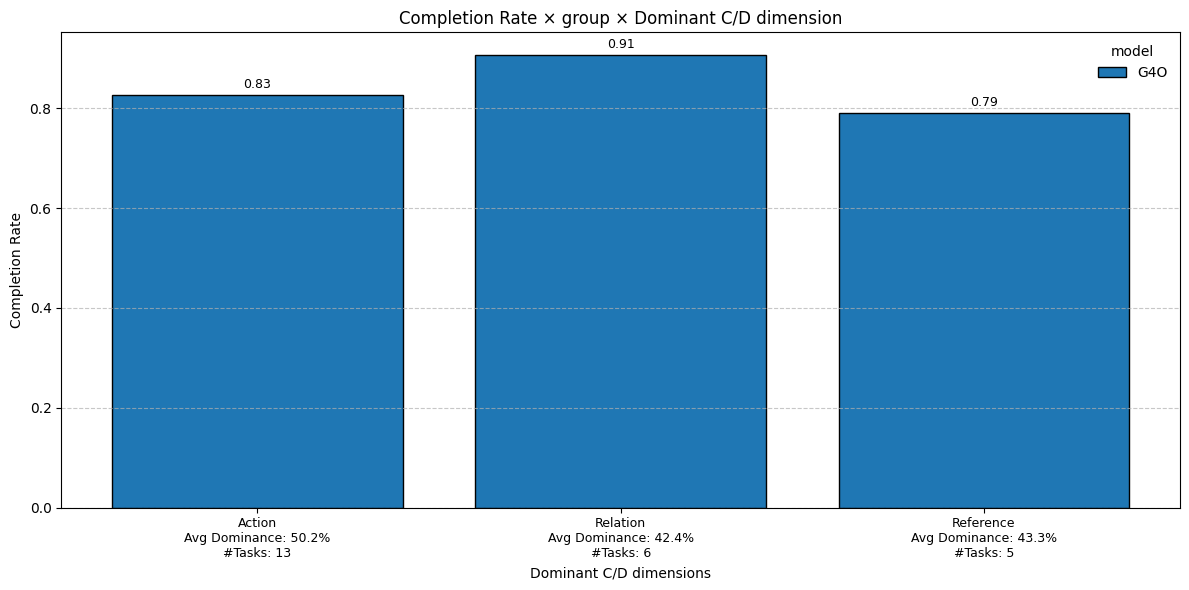

(dominant_dims    Action  Relation  Reference
 _group                                      
 G4O            0.826667  0.906489   0.790476,
            avg_dominance_pct  task_count
 dimension                               
 Action             50.233100          13
 Relation           42.356902           6
 Reference          43.333333           5,
         Action (%)  Relation (%)  Reference (%)  \
 taskId                                            
 T1      100.000000           NaN       0.000000   
 T10      33.333333     33.333333      33.333333   
 T11      36.363636     36.363636      27.272727   
 T12      60.000000     10.000000      30.000000   
 T13      33.333333     33.333333      33.333333   
 T14      55.555556     27.777778      16.666667   
 T15      50.000000     25.000000      25.000000   
 T2       50.000000           NaN      50.000000   
 T3       50.000000           NaN      50.000000   
 T4       50.000000     25.000000      25.000000   
 T5       40.000000     40

In [5]:
completion_df,dimension_dominance_df,task_dominance_df=plot_dimension_profile(out_agg[out_agg["objectIdentifier"]=="OPAQ"])
plot_dimension_profile(out_agg[out_agg["objectIdentifier"]=="SEM"])

In [6]:
completion_df

dominant_dims,Action,Relation,Reference
_group,,,


In [7]:
dimension_dominance_df

,avg_dominance_pct,task_count
dimension,,
Action,0.0,0
Relation,0.0,0
Reference,0.0,0


In [14]:
0.00 +0.08+ 1.90+ 1.69

3.67

In [15]:
0.19+ 0.19+ 1.78+ 1.59

3.75

In [16]:
1.24 +0.74 +1.97+ 1.58

5.53

In [17]:
0.53+ 0.61+ 2.00+ 1.66

4.8

In [19]:
0.62 +0.41+ 1.94+ 1.64

4.609999999999999

In [20]:
0.38 +1.10+ 1.64+ 1.45

4.57

In [23]:
0.23+ 0.25 +1.78 +1.54

3.8

In [8]:
task_dominance_df

,Action (%),Relation (%),Reference (%),dominant_dims,dominant_dim
taskId,,,,,


### 📋 Model-Level Performance Summary

This table aggregates the key performance metrics **by model**, computing the mean values across all episodes.  
The resulting table includes:

| Metric | Description |
|---------|--------------|
| **Completion Rate** | Mean solutionCheck score |
| **Token Usage** | Average totalTokens |
| **#Input Images** | Mean number of input images used |
| **Generation Time (ms)** | Average generation time |
| **#Walk / #Look / #Pick / #Drop Action** | Average counts of tool usage per action type |

**Purpose:**  
To provide a concise overview of each model’s average efficiency and behavior across all tasks.


In [6]:
summary_table=summarize_performance(out_agg[out_agg.objectIdentifier=="SEM"],by=("model","scene"),round_ndigits=6)
summary_table

,Scene,Model,Avg (reps) – Completion rate,Avg (reps) – #Model calls,Avg (reps) – Token usage (total),Avg (reps) – Token usage (last turn),Avg (reps) – #Input images (total),Avg (reps) – #Input images (last turn),Avg (reps) – Tot generation time (ms),Avg (reps) – Per-turn avg generation time (ms),Avg (reps) – Generation time per model call (ms),Avg (reps) – Tot tool time (ms),Avg (reps) – Per-turn avg tool time (ms),Avg (reps) – #Tool calls (last turn),Avg (reps) – #Walk (last turn),Avg (reps) – #Look (last turn),Avg (reps) – #Pick (last turn),Avg (reps) – #Drop (last turn)
0,S1,G4O,0.695205,9.187229,55397.507359,5639.210606,9.444805,1.084848,12596.345455,5478.450072,3222.456854,1852.218182,1003.815152,1.700866,0.321212,0.006061,0.889827,0.483766
1,S2,G4O,0.634000,18.566667,119121.806667,6127.500000,19.380000,1.013333,25738.386667,8632.960000,1892.235404,9072.480000,4538.320000,2.000000,0.280000,0.013333,0.806667,0.900000


In [29]:
summary_table=summarize_performance(out_agg,by=("model","objectIdentifier"),round_ndigits=6)
summary_table

,Model,Labeling scheme,Avg (reps) – Completion rate,Avg (reps) – #Model calls,Avg (reps) – Token usage (total),Avg (reps) – Token usage (last turn),Avg (reps) – #Input images (total),Avg (reps) – #Input images (last turn),Avg (reps) – Tot generation time (ms),Avg (reps) – Per-turn avg generation time (ms),Avg (reps) – Generation time per model call (ms),Avg (reps) – Tot tool time (ms),Avg (reps) – Per-turn avg tool time (ms),Avg (reps) – #Tool calls (last turn),Avg (reps) – #Walk (last turn),Avg (reps) – #Look (last turn),Avg (reps) – #Pick (last turn),Avg (reps) – #Drop (last turn)
0,G4O,SEM,0.869981,5.807473,46836.284567,7602.128278,9.358974,1.455604,43890.989035,6738.475104,7011.460847,6722.409768,1412.232358,4.890208,0.686862,0.473382,2.04381,1.686154


In [12]:
0.000000+	0.084444+	1.897778+	1.693333 + 1

4.675555

In [13]:
1.243810 +	0.739048 +	1.973333 +	1.581587 +1

6.537778

In [17]:
summary_table.columns

Index(['Model', 'Labeling scheme', 'Avg (reps) – Completion rate',
       'Avg (reps) – #Model calls', 'Avg (reps) – Token usage (total)',
       'Avg (reps) – Token usage (last turn)',
       'Avg (reps) – #Input images (total)',
       'Avg (reps) – #Input images (last turn)',
       'Avg (reps) – Tot generation time (ms)',
       'Avg (reps) – Per-turn avg generation time (ms)',
       'Avg (reps) – Tot tool time (ms)',
       'Avg (reps) – Per-turn avg tool time (ms)',
       'Avg (reps) – #Tool calls (last turn)',
       'Avg (reps) – #Walk (last turn)', 'Avg (reps) – #Look (last turn)',
       'Avg (reps) – #Pick (last turn)', 'Avg (reps) – #Drop (last turn)'],
      dtype='object')

In [5]:
summary_table.to_csv("summary_final_experiment_per scene.csv")